# Експеримент 09: Фінальне порівняння всіх моделей

## Мета
Створити узагальнюючі таблиці та візуалізації для всіх експериментів:
- **Fake Detection**: 01_baseline + 02 (HeadA/B/C) + 03 (HeadA/B/C) + 08_expC
- **Topic Classification**: 04_SVM_base + 05_SVM_expB + 06_BERT_base + 07_BERT_expB + 08_expC

## Результат
- Порівняльні таблиці з підсвічуванням найкращих результатів
- Групові барплоти
- Висновки та рекомендації

In [1]:
# Імпорт бібліотек
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# # # sys.path.append('..')  # Not needed  # Not needed  # Not needed
from utils.experiment_utils import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style('whitegrid')
sns.set_palette('husl')

In [2]:
# Шляхи
results_dir = 'results/'
plots_dir = 'plots/'

assert os.path.exists(results_dir), "Results directory not found"
os.makedirs(plots_dir, exist_ok=True)

print("Середовище підготовлено")

Середовище підготовлено


## 1. Завантаження всіх результатів

In [3]:
# Функція для завантаження результатів
def load_results(filename):
    """Завантаження JSON результатів"""
    path = os.path.join(results_dir, filename)
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    else:
        print(f"WARNING: {filename} не знайдено")
        return None

# Завантаження результатів для Fake Detection
fake_results = {
    '02_HeadA': load_results('02_bert_fake_headA_results.json'),
    '02_HeadB': load_results('02_bert_fake_headB_results.json'),
    '02_HeadC': load_results('02_bert_fake_headC_results.json'),
    '03_HeadA': load_results('03_bert_fake_expA_headA_results.json'),
    '03_HeadB': load_results('03_bert_fake_expA_headB_results.json'),
    '03_HeadC': load_results('03_bert_fake_expA_headC_results.json'),
    # '08_ExpC': load_results('08_expC_fake_results.json'),
}

# Завантаження результатів для Topic Classification
topic_results = {
    '04_SVM_Base': load_results('04_topic_svm_base_results.json'),
    '05_SVM_ExpB': load_results('05_topic_svm_expB_results.json'),
    '06_BERT_Base': load_results('06_bert_topic_base_results.json'),
    '07_BERT_ExpB': load_results('07_bert_topic_expB_results.json'),
    # '08_ExpC': load_results('08_expC_topic_results.json'),
}

# Видалення None значень
fake_results = {k: v for k, v in fake_results.items() if v is not None}
topic_results = {k: v for k, v in topic_results.items() if v is not None}

print(f"Завантажено {len(fake_results)} fake моделей")
print(f"Завантажено {len(topic_results)} topic моделей")

Завантажено 6 fake моделей
Завантажено 4 topic моделей


## 2. Таблиця 1: Fake Detection Models

In [4]:
# Створення таблиці для Fake Detection

def extract_fake_metrics(result):
    """Підтримує обидва формати JSON: плоский і з вкладеним ключем metrics."""
    if not isinstance(result, dict):
        return None

    metrics_block = result.get('metrics', result)
    return {
        'Accuracy': metrics_block.get('accuracy', 0),
        'Precision': metrics_block.get('precision', 0),
        'Recall': metrics_block.get('recall', 0),
        'F1-Score': metrics_block.get('f1', 0),
        'ROC-AUC': metrics_block.get('roc_auc', metrics_block.get('roc_auc_ovr_weighted', 0))
    }


fake_df_data = {}
for model_name, raw_metrics in fake_results.items():
    row = extract_fake_metrics(raw_metrics)
    if row is not None:
        fake_df_data[model_name] = row

fake_df = pd.DataFrame(fake_df_data).T

print("="*70)
print("ТАБЛИЦЯ 1: ПОРІВНЯННЯ МОДЕЛЕЙ ДЕТЕКЦІЇ ФЕЙКІВ")
print("="*70)
print(fake_df.round(4))
print()

# Стилізована таблиця з підсвічуванням максимумів
fake_styled = fake_df.style.highlight_max(color='lightgreen', axis=0)
fake_styled

ТАБЛИЦЯ 1: ПОРІВНЯННЯ МОДЕЛЕЙ ДЕТЕКЦІЇ ФЕЙКІВ
          Accuracy  Precision  Recall  F1-Score  ROC-AUC
02_HeadA    0.9243     0.9250  0.9243    0.9242   0.9829
02_HeadB    0.9270     0.9293  0.9270    0.9269   0.9823
02_HeadC    0.9295     0.9306  0.9295    0.9294   0.9827
03_HeadA    0.9203     0.9211  0.9203    0.9206   0.9811
03_HeadB    0.9272     0.9277  0.9272    0.9274   0.9807
03_HeadC    0.9244     0.9245  0.9244    0.9244   0.9814



,Accuracy,Precision,Recall,F1-Score,ROC-AUC
02_HeadA,0.924256,0.924973,0.924256,0.924224,0.982853
02_HeadB,0.927016,0.929263,0.927016,0.926920,0.982294
02_HeadC,0.929469,0.930611,0.929469,0.929422,0.982745
03_HeadA,0.920278,0.921075,0.920278,0.920572,0.981103
03_HeadB,0.927228,0.927729,0.927228,0.927424,0.980722
03_HeadC,0.924366,0.924490,0.924366,0.924424,0.981355


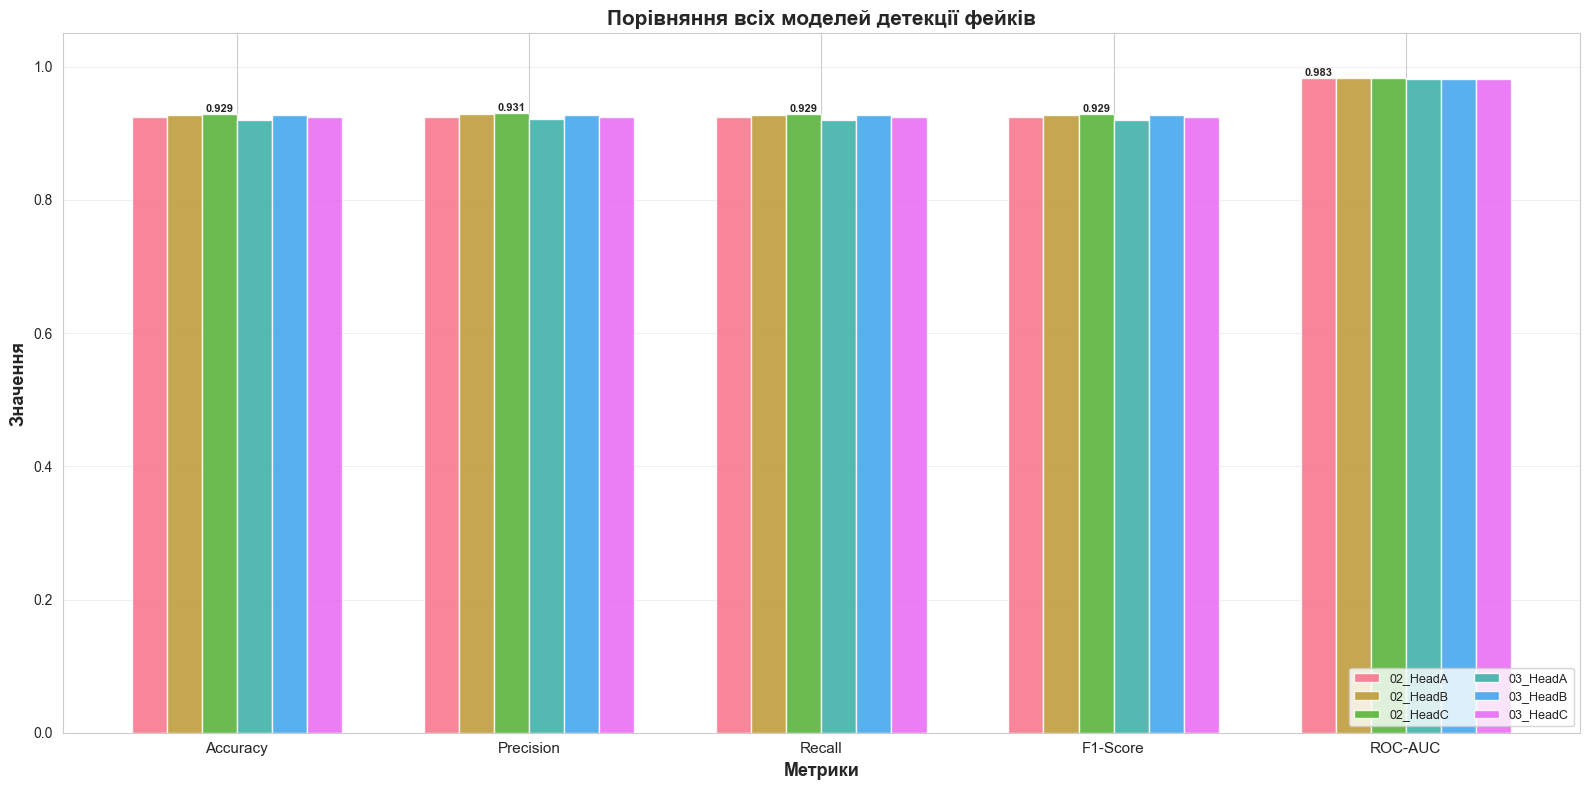

In [5]:
# Візуалізація: Grouped Bar Plot для Fake Detection
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(fake_df.columns))
width = 0.12
models = list(fake_df.index)

for i, model in enumerate(models):
    values = fake_df.loc[model].values
    offset = (i - len(models)/2) * width + width/2
    bars = ax.bar(x + offset, values, width, label=model, alpha=0.85)
    
    # Додавання значень на стовпчики (лише для найвищих)
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val == fake_df.iloc[:, j].max():
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Метрики', fontsize=13, fontweight='bold')
ax.set_ylabel('Значення', fontsize=13, fontweight='bold')
ax.set_title('Порівняння всіх моделей детекції фейків', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fake_df.columns, fontsize=11)
ax.legend(loc='lower right', ncol=2, fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}09_fake_all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 3. Таблиця 2: Topic Classification Models

In [8]:
# Створення таблиці для Topic Classification

def extract_topic_metrics(result):
    """Підтримує обидва формати JSON: плоский і з вкладеним ключем metrics."""
    if not isinstance(result, dict):
        return None

    metrics_block = result.get('metrics', result)
    row = {
        'Accuracy': metrics_block.get('accuracy', 0),
        'Macro-F1': metrics_block.get('macro_f1', metrics_block.get('f1', 0)),
        'Weighted-F1': metrics_block.get('weighted_f1', metrics_block.get('f1', 0))
    }

    per_class = result.get('per_class_f1', metrics_block.get('per_class_f1'))
    if isinstance(per_class, dict):
        for cls, f1 in per_class.items():
            row[f'F1_{cls}'] = f1

    return row


topic_df_data = {}
for model_name, raw_metrics in topic_results.items():
    row = extract_topic_metrics(raw_metrics)
    if row is not None:
        topic_df_data[model_name] = row

topic_df = pd.DataFrame(topic_df_data).T

topic_df = topic_df.reindex(sorted(topic_df.columns), axis=1)

print("="*70)
print("ТАБЛИЦЯ 2: ПОРІВНЯННЯ МОДЕЛЕЙ КЛАСИФІКАЦІЇ ТЕМ")
print("="*70)
print(topic_df.round(4))
print()

# Стилізована таблиця
topic_styled = topic_df.style.highlight_max(color='lightgreen', axis=0)
topic_styled

ТАБЛИЦЯ 2: ПОРІВНЯННЯ МОДЕЛЕЙ КЛАСИФІКАЦІЇ ТЕМ
              Accuracy  F1_бізнес  F1_новини  F1_політика  F1_спорт  \
04_SVM_Base     0.9213     0.9318     0.8552       0.8840     0.988   
05_SVM_ExpB     0.9675     0.9429        NaN       0.9633     0.994   
06_BERT_Base    0.9459        NaN        NaN          NaN       NaN   
07_BERT_ExpB    0.9772        NaN        NaN          NaN       NaN   

              F1_технології  Macro-F1  Weighted-F1  
04_SVM_Base          0.9456    0.9209       0.9209  
05_SVM_ExpB          0.9699    0.9675       0.9675  
06_BERT_Base            NaN    0.9459       0.9459  
07_BERT_ExpB            NaN    0.9772       0.9772  



,Accuracy,F1_бізнес,F1_новини,F1_політика,F1_спорт,F1_технології,Macro-F1,Weighted-F1
04_SVM_Base,0.921300,0.931784,0.855179,0.883967,0.988018,0.945625,0.920915,0.920915
05_SVM_ExpB,0.967500,0.942871,nan,0.963300,0.994009,0.969878,0.967515,0.967515
06_BERT_Base,0.945867,nan,nan,nan,nan,nan,0.945878,0.945878
07_BERT_ExpB,0.977167,nan,nan,nan,nan,nan,0.977161,0.977161


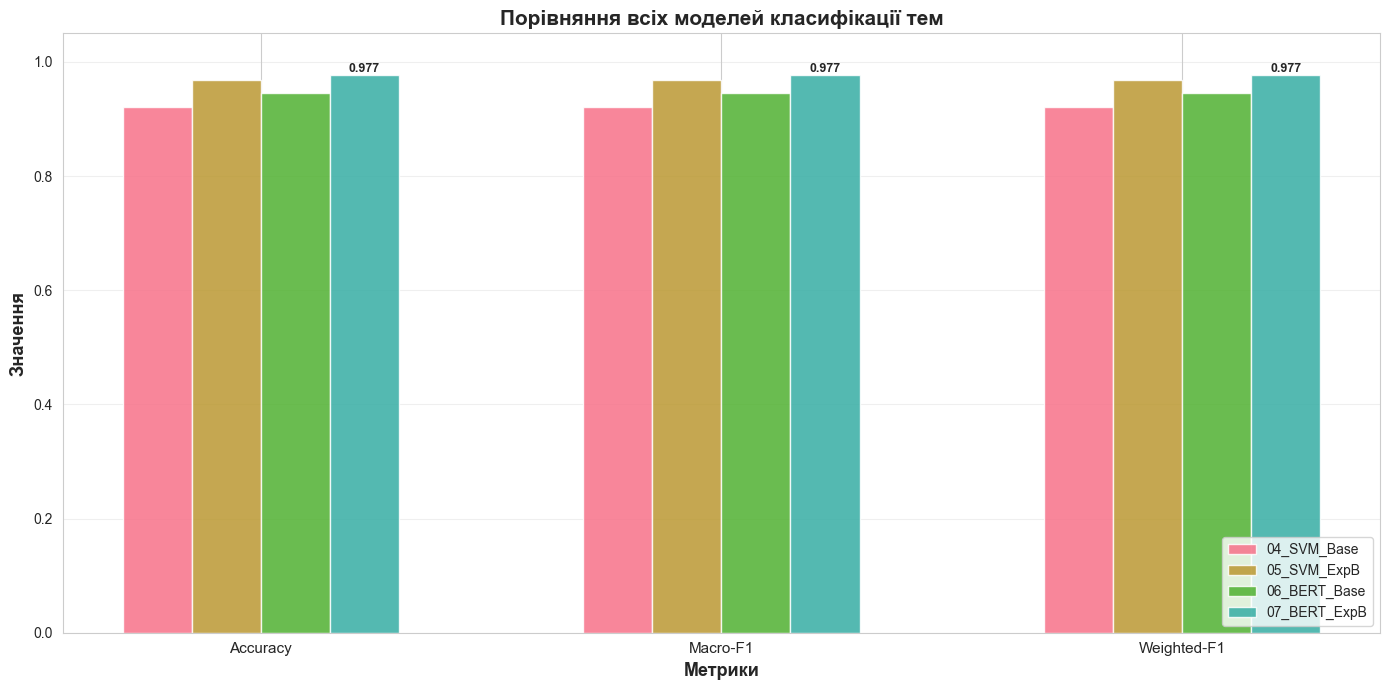

In [9]:
# Візуалізація: Grouped Bar Plot для Topic Classification (основні метрики)
fig, ax = plt.subplots(figsize=(14, 7))

main_metrics = ['Accuracy', 'Macro-F1', 'Weighted-F1']
topic_df_main = topic_df[main_metrics]

x = np.arange(len(main_metrics))
width = 0.15
models = list(topic_df_main.index)

for i, model in enumerate(models):
    values = topic_df_main.loc[model].values
    offset = (i - len(models)/2) * width + width/2
    bars = ax.bar(x + offset, values, width, label=model, alpha=0.85)
    
    # Додавання значень для максимумів
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val == topic_df_main.iloc[:, j].max():
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Метрики', fontsize=13, fontweight='bold')
ax.set_ylabel('Значення', fontsize=13, fontweight='bold')
ax.set_title('Порівняння всіх моделей класифікації тем', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(main_metrics, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}09_topic_all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 4. Аналіз найкращих моделей

In [10]:
# Визначення найкращих моделей
print("="*70)
print("АНАЛІЗ НАЙКРАЩИХ МОДЕЛЕЙ")
print("="*70)

print("\n=== FAKE DETECTION ===")
for metric in fake_df.columns:
    best_model = fake_df[metric].idxmax()
    best_value = fake_df[metric].max()
    print(f"{metric:12s}: {best_model:15s} ({best_value:.4f})")

print("\n=== TOPIC CLASSIFICATION ===")
for metric in main_metrics:
    best_model = topic_df[metric].idxmax()
    best_value = topic_df[metric].max()
    print(f"{metric:15s}: {best_model:15s} ({best_value:.4f})")

АНАЛІЗ НАЙКРАЩИХ МОДЕЛЕЙ

=== FAKE DETECTION ===
Accuracy    : 02_HeadC        (0.9295)
Precision   : 02_HeadC        (0.9306)
Recall      : 02_HeadC        (0.9295)
F1-Score    : 02_HeadC        (0.9294)
ROC-AUC     : 02_HeadA        (0.9829)

=== TOPIC CLASSIFICATION ===
Accuracy       : 07_BERT_ExpB    (0.9772)
Macro-F1       : 07_BERT_ExpB    (0.9772)
Weighted-F1    : 07_BERT_ExpB    (0.9772)


## 5. Порівняння Base vs Experimental умов

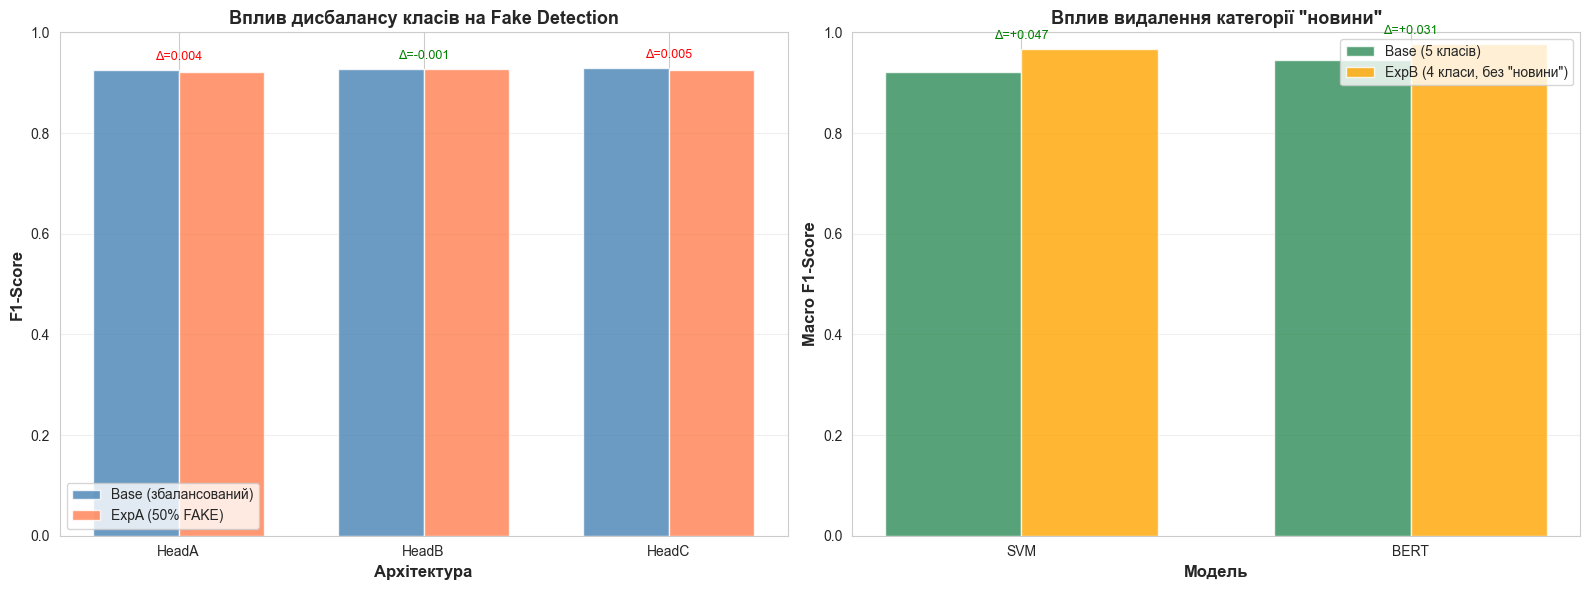

In [12]:
# Аналіз впливу експериментальних умов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

def get_fake_f1(result):
    metrics_block = result.get('metrics', result) if isinstance(result, dict) else {}
    return metrics_block.get('f1', metrics_block.get('macro_f1', 0))


# Fake: Base (02) vs ExpA (03)
heads = ['HeadA', 'HeadB', 'HeadC']
base_f1 = [get_fake_f1(fake_results[f'02_{h}']) for h in heads if f'02_{h}' in fake_results]
expA_f1 = [get_fake_f1(fake_results[f'03_{h}']) for h in heads if f'03_{h}' in fake_results]

x_fake = np.arange(len(heads))
width = 0.35
ax1.bar(x_fake - width/2, base_f1, width, label='Base (збалансований)', alpha=0.8, color='steelblue')
ax1.bar(x_fake + width/2, expA_f1, width, label='ExpA (50% FAKE)', alpha=0.8, color='coral')
ax1.set_xlabel('Архітектура', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('Вплив дисбалансу класів на Fake Detection', fontsize=13, fontweight='bold')
ax1.set_xticks(x_fake)
ax1.set_xticklabels(heads)
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(True, axis='y', alpha=0.3)

# Додавання різниці
for i, (b, e) in enumerate(zip(base_f1, expA_f1)):
    diff = b - e
    ax1.text(i, max(b, e) + 0.02, f'Δ={diff:.3f}', ha='center', fontsize=9, color='red' if diff > 0 else 'green')


def get_topic_macro_f1(result):
    metrics_block = result.get('metrics', result) if isinstance(result, dict) else {}
    return metrics_block.get('macro_f1', metrics_block.get('f1', 0))


# Topic: Base (5 класів) vs ExpB (4 класи)
if '04_SVM_Base' in topic_results and '05_SVM_ExpB' in topic_results:
    svm_base_f1 = get_topic_macro_f1(topic_results['04_SVM_Base'])
    svm_expB_f1 = get_topic_macro_f1(topic_results['05_SVM_ExpB'])
else:
    svm_base_f1, svm_expB_f1 = 0, 0

if '06_BERT_Base' in topic_results and '07_BERT_ExpB' in topic_results:
    bert_base_f1 = get_topic_macro_f1(topic_results['06_BERT_Base'])
    bert_expB_f1 = get_topic_macro_f1(topic_results['07_BERT_ExpB'])
else:
    bert_base_f1, bert_expB_f1 = 0, 0

models_topic = ['SVM', 'BERT']
base_vals = [svm_base_f1, bert_base_f1]
expB_vals = [svm_expB_f1, bert_expB_f1]

x_topic = np.arange(len(models_topic))
ax2.bar(x_topic - width/2, base_vals, width, label='Base (5 класів)', alpha=0.8, color='seagreen')
ax2.bar(x_topic + width/2, expB_vals, width, label='ExpB (4 класи, без "новини")', alpha=0.8, color='orange')
ax2.set_xlabel('Модель', fontsize=12, fontweight='bold')
ax2.set_ylabel('Macro F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('Вплив видалення категорії "новини"', fontsize=13, fontweight='bold')
ax2.set_xticks(x_topic)
ax2.set_xticklabels(models_topic)
ax2.legend()
ax2.set_ylim(0, 1)
ax2.grid(True, axis='y', alpha=0.3)

# Додавання різниці
for i, (b, e) in enumerate(zip(base_vals, expB_vals)):
    diff = e - b  # ExpB - Base (позитивна різниця = покращення)
    ax2.text(i, max(b, e) + 0.02, f'Δ={diff:+.3f}', ha='center', fontsize=9, color='green' if diff > 0 else 'red')

plt.tight_layout()
plt.savefig(f'{plots_dir}09_base_vs_experimental_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 6. Збереження фінальних результатів

In [13]:
# Збереження зведених таблиць
fake_df.to_csv(f'{results_dir}09_fake_detection_summary.csv')
topic_df.to_csv(f'{results_dir}09_topic_classification_summary.csv')

# Створення фінального звіту
summary_report = {
    'fake_detection': {
        'models_compared': len(fake_results),
        'best_overall': fake_df['F1-Score'].idxmax(),
        'best_f1': float(fake_df['F1-Score'].max()),
        'best_roc_auc': float(fake_df['ROC-AUC'].max())
    },
    'topic_classification': {
        'models_compared': len(topic_results),
        'best_overall': topic_df['Macro-F1'].idxmax(),
        'best_macro_f1': float(topic_df['Macro-F1'].max()),
        'best_accuracy': float(topic_df['Accuracy'].max())
    }
}

with open(f'{results_dir}09_final_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_report, f, ensure_ascii=False, indent=2)

print("="*70)
print("ФІНАЛЬНИЙ ЗВІТ ЗБЕРЕЖЕНО")
print("="*70)
print(f"Таблиці: {results_dir}09_[fake|topic]_summary.csv")
print(f"Звіт: {results_dir}09_final_summary.json")
print(f"Графіки: {plots_dir}09_*.png")

ФІНАЛЬНИЙ ЗВІТ ЗБЕРЕЖЕНО
Таблиці: results/09_[fake|topic]_summary.csv
Звіт: results/09_final_summary.json
Графіки: plots/09_*.png


## 7. Висновки та рекомендації

### Fake Detection

**Порівняння архітектур:**
- HeadA (проста лінійна): Баланс між швидкістю та точністю
- HeadB (двошарова з BatchNorm): Потенційно краща генералізація
- HeadC (Attention Pooling): Використання контексту з усього тексту

**Вплив дисбалансу:**
- Експеримент ExpA (50% FAKE) показує деградацію метрик
- Найбільше страждає Recall для класу FAKE
- Рекомендації: використання class weights або oversampling

### Topic Classification

**SVM vs BERT:**
- SVM: Швидше, менше ресурсів, хороші результати для структурованих тем
- BERT: Краще розуміння контексту, вища точність на складних прикладах

**Вплив видалення категорії "новини":**
- ExpB (4 класи) може показати покращення через видалення неспецифічного класу
- Краще розділення між специфічними темами (політика, спорт, технології, бізнес)

### Загальні висновки

1. **Вибір моделі залежить від контексту:**
   - Для продакшену з обмеженими ресурсами: SVM для тем, HeadA для фейків
   - Для максимальної точності: BERT з найкращою головою

2. **Якість даних критична:**
   - Збалансованість класів суттєво впливає на результати
   - Специфічність категорій покращує класифікацію

3. **Рекомендації для покращення:**
   - Fake: Ensemble з кількох голов, аугментація даних
   - Topic: Fine-tuning BERT довше, використання domain-specific embeddings

---

**Експерименти завершено. Всі результати збережено та візуалізовано.**